<a href="https://colab.research.google.com/github/YouriKaufmann/CVaR-Tool/blob/main/V3_EN_Climate_Stress_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

In [ ]:
# ── 1. Mount Google Drive ─────────────────────────────────────────────────────
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ── 2. Read company data ──────────────────────────────────────────────────────
chemin_excel = '/content/drive/MyDrive/Stress Test Climatique/Analyses/2 - Sportswear/2 - Final/Données Statiques Entreprises Sportswear- CVaR.xlsx'
df_companies = pd.read_excel(chemin_excel, sheet_name='Companies')

# 2b. Force numeric conversion on all financial columns
numeric_cols = [
    'Market_Cap', 'Total_Debt', 'Beta', 'Interest_Expense',
    'EBITDA', 'Total_Revenue', 'Scope_1_2', 'Scope_3',
    '%_of_Green_Revenue', 'Pass_Through',
    'Scope_3_SBTi_Current', 'Scope_3_SBTi_Baseline',
    'Carbon_Reduction_Plan_Scope_3', 'SBTi_Baseline_Year', 'SBTi_Target_Year'
]
for col in numeric_cols:
    if col in df_companies.columns:
        df_companies[col] = (
            df_companies[col]
            .astype(str)
            .str.replace(' ', '', regex=False)
            .str.replace(',', '.', regex=False)
            .pipe(pd.to_numeric, errors='coerce')
        )

# 2c. Financial data entered in millions — convert to absolute units
millions_cols = [
    'Market_Cap', 'Total_Debt', 'Interest_Expense',
    'EBITDA', 'Total_Revenue'
]
for col in millions_cols:
    if col in df_companies.columns:
        df_companies[col] = df_companies[col] * 1_000_000

In [ ]:
# ── 3. Read FX rates from Currencies sheet ────────────────────────────────────
df_currencies = pd.read_excel(chemin_excel, sheet_name='Currencies')
fx_map = df_currencies.set_index('Currency')['Value'].to_dict()

CURRENCY_TO_EUR = {'EUR': 1.0}  # EUR is always 1.0, not stored in sheet
CURRENCY_TO_EUR.update(fx_map)  # adds USD, CHF, GBP, DKK from Excel

In [ ]:
# ── 4. Read carbon price trajectory from Carbon_Prices sheet ─────────────────
# Expected columns: Year / Current_Policies / Delayed_Transition / Net_Zero_2050
# Minimum required anchor points: 2025, 2030, 2035
df_carbon = pd.read_excel(chemin_excel, sheet_name='Carbon_Prices')
df_carbon = df_carbon.sort_values('Year').set_index('Year')

# Force numeric conversion on all price columns
for col in df_carbon.columns:
    df_carbon[col] = (
        df_carbon[col]
        .astype(str)
        .str.replace(' ', '', regex=False)
        .str.replace(',', '.', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )
# Also ensure the index (Year) is integer
df_carbon.index = df_carbon.index.astype(int)

# Build annual trajectory 2025→2035 (11 years) by linear interpolation
BASE_YEAR      = 2025
HORIZON        = 11  # default — overridden in the scenario loop
HORIZON_FULL   = 11  # 2025→2035
HORIZON_MID    = 6   # 2025→2030

years_full = list(range(BASE_YEAR, BASE_YEAR + HORIZON_FULL))  # [2025, ..., 2035]
df_carbon_interp = df_carbon.reindex(years_full).interpolate(method='index')

# Build scenario dictionary — arrays of length HORIZON_FULL
CARBON_TRAJECTORY = {
    'Current_Policies':   df_carbon_interp['Current_Policies'].values,
    'Delayed_Transition': df_carbon_interp['Delayed_Transition'].values,
    'Net_Zero_2050':      df_carbon_interp['Net_Zero_2050'].values,
}

# Active scenario — updated at each loop iteration
ACTIVE_SCENARIO = 'Delayed_Transition'

print("FX rates loaded:", CURRENCY_TO_EUR)
for scenario, prices in CARBON_TRAJECTORY.items():
    print(f"\nCarbon price trajectory ({scenario}):")
    for yr, price in zip(years_full, prices):
        print(f"  {yr}: €{price:.2f}/tCO2e")
print(df_companies)

FX rates loaded: {'EUR': 1.0, 'USD': 0.855, 'CHF': 0.985, 'GBP': 1.13, 'DKK': 0.134}

Carbon price trajectory (Current_Policies):
  2025: €0.00/tCO2e
  2026: €0.00/tCO2e
  2027: €0.00/tCO2e
  2028: €0.00/tCO2e
  2029: €0.00/tCO2e
  2030: €0.00/tCO2e
  2031: €0.00/tCO2e
  2032: €0.00/tCO2e
  2033: €0.00/tCO2e
  2034: €0.00/tCO2e
  2035: €0.00/tCO2e

Carbon price trajectory (Delayed_Transition):
  2025: €0.00/tCO2e
  2026: €0.00/tCO2e
  2027: €0.00/tCO2e
  2028: €0.00/tCO2e
  2029: €0.00/tCO2e
  2030: €0.00/tCO2e
  2031: €19.09/tCO2e
  2032: €38.19/tCO2e
  2033: €57.28/tCO2e
  2034: €76.38/tCO2e
  2035: €95.47/tCO2e

Carbon price trajectory (Net_Zero_2050):
  2025: €15.60/tCO2e
  2026: €38.07/tCO2e
  2027: €60.54/tCO2e
  2028: €83.00/tCO2e
  2029: €105.47/tCO2e
  2030: €127.94/tCO2e
  2031: €152.05/tCO2e
  2032: €176.16/tCO2e
  2033: €200.28/tCO2e
  2034: €224.39/tCO2e
  2035: €248.50/tCO2e
           Name  Ticker Currency    Market_Cap    Total_Debt    Beta  \
0        Adidas  ADS.DE   

In [ ]:
# ── 5. Scenario & WACC parameters ─────────────────────────────────────────────
GREEN_MARKET_GROWTH = 0

RISK_FREE_RATE      = 0.0440   # US Treasury 10Y — Damodaran, May 2026
MARKET_RISK_PREMIUM = 0.0424   # Implied ERP — Damodaran, May 1, 2026
CORPORATE_TAX_RATE  = 0.25
DATA_YEAR           = 2024     # year of collected data

In [ ]:
# ── 6. Core functions ─────────────────────────────────────────────────────────

def calculate_wacc(row, conversion_rate):
    """
    Computes company-specific WACC from static Excel inputs.
    All monetary values are in native currency; conversion_rate converts to EUR.
    """
    try:
        market_cap    = row['Market_Cap'] * conversion_rate
        total_debt    = row['Total_Debt'] * conversion_rate
        total_capital = market_cap + total_debt

        if total_capital == 0:
            return 0.071  # fallback

        weight_equity = market_cap / total_capital
        weight_debt   = total_debt / total_capital

        beta = row.get('Beta', 1.0)
        if pd.isna(beta) or beta <= 0:
            beta = 1.0

        cost_of_equity = RISK_FREE_RATE + beta * MARKET_RISK_PREMIUM

        interest_expense = abs(row.get('Interest_Expense', 0)) * conversion_rate
        if total_debt > 0 and interest_expense > 0:
            cost_of_debt = interest_expense / total_debt
        else:
            cost_of_debt = 0.04  # fallback for companies with no financial debt

        wacc = (weight_equity * cost_of_equity) + \
               (weight_debt * cost_of_debt * (1 - CORPORATE_TAX_RATE))
        return round(wacc, 4)

    except Exception:
        return 0.071


def compute_scope3_reduction(scope3_total_current, scope3_sbti_current,
                             scope3_sbti_baseline, reduction_plan,
                             sbti_target_year, current_year):
    """
    Returns the effective Scope 3 reduction rate for a given year,
    assuming linear progression from 0 (current_year=BASE_YEAR)
    to full reduction (current_year=sbti_target_year).
    After sbti_target_year, reduction stays at maximum.

    Note: reduction starts from 0 in BASE_YEAR (2025), using current emissions
    as the starting point. Reductions already achieved vs baseline are captured
    in the SBTi tracking table but not re-applied here to avoid double-counting.
    """
    try:
        if pd.isna(scope3_sbti_baseline) or pd.isna(reduction_plan) or pd.isna(scope3_sbti_current):
            return 0.0
        if scope3_total_current <= 0 or scope3_sbti_current <= 0 or scope3_sbti_baseline <= 0:
            return 0.0

        target_sbti        = scope3_sbti_baseline * (1 - reduction_plan)
        eff_reduction_sbti = max(0.0, 1 - (target_sbti / scope3_sbti_current))
        coverage           = scope3_sbti_current / scope3_total_current
        full_reduction     = eff_reduction_sbti * coverage

        if current_year >= sbti_target_year:
            progress = 1.0
        else:
            progress = (current_year - BASE_YEAR) / (sbti_target_year - BASE_YEAR)
            progress = max(0.0, progress)

        return full_reduction * progress

    except Exception:
        return 0.0


def calculate_cvar_and_sector(row, with_transition_plan=False):
    """
    Computes CVaR scores for a company from static Excel data.
    Uses global HORIZON and ACTIVE_SCENARIO.
    """
    try:
        currency        = row.get('Currency', 'USD')
        conversion_rate = CURRENCY_TO_EUR.get(currency, 0.855)

        ebitda  = row['EBITDA'] * conversion_rate
        mkt_cap = row['Market_Cap'] * conversion_rate

        if ebitda == 0 or mkt_cap == 0:
            return pd.Series([None, None])

        wacc = calculate_wacc(row, conversion_rate)

        carbon_prices        = CARBON_TRAJECTORY[ACTIVE_SCENARIO][:HORIZON]
        sbti_target_year_raw = row.get('SBTi_Target_Year', 2035)
        sbti_target_year     = 2035 if pd.isna(sbti_target_year_raw) else int(sbti_target_year_raw)

        pv_impact = 0.0
        for t in range(HORIZON):
            current_year = BASE_YEAR + t

            if with_transition_plan:
                eff_red_3_t = compute_scope3_reduction(
                    scope3_total_current = row['Scope_3'],
                    scope3_sbti_current  = row.get('Scope_3_SBTi_Current', np.nan),
                    scope3_sbti_baseline = row.get('Scope_3_SBTi_Baseline', np.nan),
                    reduction_plan       = row.get('Carbon_Reduction_Plan_Scope_3', np.nan),
                    sbti_target_year     = sbti_target_year,
                    current_year         = current_year
                )
                scope_3_t = row['Scope_3'] * (1 - eff_red_3_t)
            else:
                scope_3_t = row['Scope_3']

            total_emissions_t = row['Scope_1_2'] + scope_3_t
            price_t           = carbon_prices[t]
            gross_t           = total_emissions_t * price_t
            net_t             = gross_t * (1 - row['Pass_Through'])
            upside_t          = ebitda * row['%_of_Green_Revenue'] * GREEN_MARKET_GROWTH
            delta_cf_t        = upside_t - net_t
            pv_impact        += delta_cf_t / ((1 + wacc) ** (t + 1))

        cvar_score_mktcap = round((pv_impact / mkt_cap) * 100, 2)
        cvar_score_ebitda = round((pv_impact / ebitda) * 100, 2)

        return pd.Series([cvar_score_mktcap, cvar_score_ebitda])

    except Exception as e:
        print(f"Error for {row.get('Ticker', '?')}: {type(e).__name__} — {e}")
        return pd.Series([None, None])


def compute_intermediates(row, carbon_prices):
    """
    Computes NPV of intermediate carbon cost variables for Table 3.
    Returns both baseline and with_plan versions for full auditability.
    Uses global HORIZON.
    """
    conv   = CURRENCY_TO_EUR.get(row.get('Currency', 'USD'), 0.855)
    ebitda = row['EBITDA'] * conv
    wacc   = calculate_wacc(row, conv)

    sbti_target_year_raw = row.get('SBTi_Target_Year', 2035)
    sbti_target_year     = 2035 if pd.isna(sbti_target_year_raw) else int(sbti_target_year_raw)

    gross, net, upside, cumul_no_plan, cumul_with_plan = 0, 0, 0, 0, 0

    for t in range(HORIZON):
        current_year = BASE_YEAR + t
        price_t      = carbon_prices[t]

        gross_t = (row['Scope_1_2'] + row['Scope_3']) * price_t
        net_t   = gross_t * (1 - row['Pass_Through'])
        up_t    = ebitda * row['%_of_Green_Revenue'] * GREEN_MARKET_GROWTH
        disc    = (1 + wacc) ** (t + 1)

        gross         += gross_t / disc
        net           += net_t   / disc
        upside        += up_t    / disc
        cumul_no_plan += (up_t - net_t) / disc

        eff_red_3_t = compute_scope3_reduction(
            scope3_total_current = row['Scope_3'],
            scope3_sbti_current  = row.get('Scope_3_SBTi_Current', np.nan),
            scope3_sbti_baseline = row.get('Scope_3_SBTi_Baseline', np.nan),
            reduction_plan       = row.get('Carbon_Reduction_Plan_Scope_3', np.nan),
            sbti_target_year     = sbti_target_year,
            current_year         = current_year
        )
        scope_3_with_plan   = row['Scope_3'] * (1 - eff_red_3_t)
        gross_with_t        = (row['Scope_1_2'] + scope_3_with_plan) * price_t
        net_with_t          = gross_with_t * (1 - row['Pass_Through'])
        cumul_with_plan    += (up_t - net_with_t) / disc

    annual_avg           = cumul_no_plan   / HORIZON
    annual_avg_with_plan = cumul_with_plan / HORIZON

    return pd.Series({
        'gross_carbon_cost':       gross,
        'net_carbon_cost':         net,
        'Green_Upside':            upside,
        'annual_net_impact_avg':   annual_avg,
        'Annual_net_impact_WPlan': annual_avg_with_plan,
        'Cumulative_Impact':       cumul_no_plan,
        'Cumulative_Impact_WPlan': cumul_with_plan,
    })


def compute_sbti_tracking(row):
    """
    Computes SBTi progress tracking indicators.
    Returns a dict with all metrics; None for companies without SBTi data.
    """
    result = {
        'SBTi_Progress_Pct':        None,
        'SBTi_Target_Pct':          None,
        'SBTi_Remaining_Pct':       None,
        'SBTi_Years_Remaining':     None,
        'SBTi_Rate_Required_PctYr': None,
        'SBTi_Rate_Observed_PctYr': None,
        'SBTi_Acceleration_Factor': None,
    }
    try:
        baseline      = row.get('Scope_3_SBTi_Baseline', np.nan)
        current       = row.get('Scope_3_SBTi_Current', np.nan)
        target_pct    = row.get('Carbon_Reduction_Plan_Scope_3', np.nan)
        target_year   = row.get('SBTi_Target_Year', np.nan)
        baseline_year = row.get('SBTi_Baseline_Year', np.nan)

        if any(pd.isna(v) or v == 0 for v in [baseline, current, target_pct, target_year, baseline_year]):
            return result

        progress_pct    = (baseline - current) / baseline
        remaining_pct   = max(0.0, target_pct - progress_pct)
        years_remaining = target_year - DATA_YEAR
        years_elapsed   = DATA_YEAR - baseline_year

        rate_required = remaining_pct / years_remaining if years_remaining > 0 else None
        rate_observed = progress_pct / years_elapsed   if years_elapsed  > 0 else None
        accel         = (rate_required / rate_observed) if (rate_required and rate_observed and rate_observed > 0) else None

        result.update({
            'SBTi_Progress_Pct':        round(progress_pct * 100, 1),
            'SBTi_Target_Pct':          round(target_pct * 100, 1),
            'SBTi_Remaining_Pct':       round(remaining_pct * 100, 1),
            'SBTi_Years_Remaining':     int(years_remaining),
            'SBTi_Rate_Required_PctYr': round(rate_required * 100, 2) if rate_required else None,
            'SBTi_Rate_Observed_PctYr': round(rate_observed * 100, 2) if rate_observed else None,
            'SBTi_Acceleration_Factor': round(accel, 2) if accel else None,
        })
    except Exception:
        pass
    return result

In [ ]:
# ── 7. Display functions ──────────────────────────────────────────────────────

def display_table_1_financial(df):
    """Fixed financial data."""
    def get_cost_of_debt(row):
        currency   = row.get('Currency', 'USD')
        conv       = CURRENCY_TO_EUR.get(currency, 0.855)
        total_debt = row['Total_Debt'] * conv
        interest   = abs(row.get('Interest_Expense', 0)) * conv
        if total_debt > 0 and interest > 0:
            return round(interest / total_debt * 100, 2)
        return None  # displays '—' for companies with no financial debt

    df = df.copy()
    df['Cost_of_Debt_Pct'] = df.apply(get_cost_of_debt, axis=1)
    df['Debt_EBITDA']      = (df['Total_Debt'] / df['EBITDA']).round(2)

    cols = ['Name', 'Ticker', 'Currency',
            'Market_Cap', 'EBITDA', 'Total_Revenue',
            'Total_Debt', 'Interest_Expense',
            'Debt_EBITDA', 'Beta', 'Cost_of_Debt_Pct', 'WACC']

    df_display = df[cols].copy()
    return df_display.reset_index(drop=True).style \
        .set_caption("Table 1 — Financial Data") \
        .format({
            'Market_Cap':       lambda x: f"{x/1e9:,.1f} Md",
            'EBITDA':           lambda x: f"{x/1e6:,.0f} M",
            'Total_Revenue':    lambda x: f"{x/1e6:,.0f} M",
            'Total_Debt':       lambda x: f"{x/1e6:,.0f} M",
            'Interest_Expense': lambda x: f"{x/1e6:,.0f} M",
            'Debt_EBITDA':      '{:.1f}x',
            'Beta':             '{:.3f}',
            'Cost_of_Debt_Pct': '{:.2f}%',
            'WACC':             '{:.2%}',
        }, na_rep='—') \
        .set_properties(**{'text-align': 'right', 'font-size': '12px'}) \
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('text-align', 'center')]},
            {'selector': 'caption', 'props': [('font-size', '15px'), ('font-weight', 'bold'), ('padding', '8px')]}
        ])


def display_table_2_esg(df):
    """Fixed ESG data + SBTi tracking."""
    cols = [
        'Name', 'Ticker', 'Currency',
        'Scope_1_2', 'Scope_3', 'carbon_intensity',
        'Pass_Through', '%_of_Green_Revenue',
        'Scope_3_SBTi_Baseline', 'Scope_3_SBTi_Current',
        'Carbon_Reduction_Plan_Scope_3', 'SBTi_Baseline_Year', 'SBTi_Target_Year',
        'SBTi_Progress_Pct', 'SBTi_Target_Pct', 'SBTi_Remaining_Pct',
        'SBTi_Years_Remaining',
        'SBTi_Rate_Observed_PctYr', 'SBTi_Rate_Required_PctYr',
        'SBTi_Acceleration_Factor',
    ]
    df = df.copy()
    df['carbon_intensity'] = df.apply(
        lambda r: round((r['Scope_1_2'] + r['Scope_3']) /
                        (r['Total_Revenue'] * CURRENCY_TO_EUR.get(r.get('Currency', 'USD'), 0.855) / 1e6), 1)
        if r['Total_Revenue'] > 0 else None, axis=1)

    df_display = df[[c for c in cols if c in df.columns]].copy()
    df_display = df_display.loc[:, ~df_display.columns.duplicated()]

    def accel_color(val):
        if pd.isna(val): return ''
        if val <= 1.0:   return 'color: #27ae60; font-weight: bold'
        if val <= 1.5:   return 'color: #f39c12; font-weight: bold'
        return 'color: #e74c3c; font-weight: bold'

    return df_display.reset_index(drop=True).style \
        .set_caption("Table 2 — ESG & SBTi Tracking Data") \
        .format({
            'Scope_1_2':                     '{:,.0f} tCO2e',
            'Scope_3':                       '{:,.0f} tCO2e',
            'carbon_intensity':              '{:,.0f} tCO2e/M€',
            'Pass_Through':                  '{:.0%}',
            '%_of_Green_Revenue':            '{:.0%}',
            'Scope_3_SBTi_Baseline':         '{:,.0f} tCO2e',
            'Scope_3_SBTi_Current':          '{:,.0f} tCO2e',
            'Carbon_Reduction_Plan_Scope_3': '{:.0%}',
            'SBTi_Progress_Pct':             '{:.1f}%',
            'SBTi_Target_Pct':               '{:.1f}%',
            'SBTi_Remaining_Pct':            '{:.1f}%',
            'SBTi_Rate_Observed_PctYr':      '{:.2f}%/yr',
            'SBTi_Rate_Required_PctYr':      '{:.2f}%/yr',
            'SBTi_Acceleration_Factor':      '{:.2f}x',
            'SBTi_Baseline_Year':            '{:.0f}',
            'SBTi_Target_Year':              '{:.0f}',
            'SBTi_Years_Remaining':          '{:.0f}',
        }, na_rep='—') \
        .map(accel_color, subset=['SBTi_Acceleration_Factor']) \
        .set_properties(**{'text-align': 'right', 'font-size': '12px'}) \
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#1a5276'), ('color', 'white'), ('text-align', 'center')]},
            {'selector': 'caption', 'props': [('font-size', '15px'), ('font-weight', 'bold'), ('padding', '8px')]}
        ])


def display_table_3_scenario(df_run, scenario, horizon_year, carbon_prices):
    """Scenario results for a given scenario and horizon."""
    carbon_2025   = carbon_prices[0]
    carbon_horizon = carbon_prices[-1]

    cols = [
        'Name', 'Ticker',
        'gross_carbon_cost', 'net_carbon_cost',
        'Green_Upside',
        'annual_net_impact_avg',
        'Cumulative_Impact',
        'Annual_net_impact_WPlan',
        'Cumulative_Impact_WPlan',
        'CVaR_MktCap_NoPlan', 'CVaR_EBITDA_NoPlan',
        'CVaR_MktCap_WithPlan', 'CVaR_EBITDA_WithPlan',
        'Delta_MktCap', 'Delta_EBITDA'
    ]
    df_display = df_run[[c for c in cols if c in df_run.columns]].copy()

    return df_display.reset_index(drop=True).style \
        .set_caption(
            f"Table 3 — Scenario: {scenario} — Horizon 2025→{horizon_year} "
            f"| Carbon price: €{carbon_2025:.0f} (2025) → €{carbon_horizon:.0f}/tCO2e ({horizon_year})"
        ) \
        .format({
            'gross_carbon_cost':       lambda x: f"-{x/1e6:,.1f} M€" if pd.notna(x) else '—',
            'net_carbon_cost':         lambda x: f"-{x/1e6:,.1f} M€" if pd.notna(x) else '—',
            'Green_Upside':            lambda x: f"+{x/1e6:,.1f} M€" if pd.notna(x) else '—',
            'annual_net_impact_avg':   lambda x: f"{x/1e6:,.1f} M€"  if pd.notna(x) else '—',
            'Cumulative_Impact':       lambda x: f"{x/1e6:,.1f} M€"  if pd.notna(x) else '—',
            'Annual_net_impact_WPlan': lambda x: f"{x/1e6:,.1f} M€"  if pd.notna(x) else '—',
            'Cumulative_Impact_WPlan': lambda x: f"{x/1e6:,.1f} M€"  if pd.notna(x) else '—',
            'CVaR_MktCap_NoPlan':      '{:+.2f}%',
            'CVaR_EBITDA_NoPlan':      '{:+.2f}%',
            'CVaR_MktCap_WithPlan':    '{:+.2f}%',
            'CVaR_EBITDA_WithPlan':    '{:+.2f}%',
            'Delta_MktCap':            '{:+.2f} pp',
            'Delta_EBITDA':            '{:+.2f} pp',
        }, na_rep='—') \
        .map(lambda v: f'color: {"#e74c3c" if v < 0 else "#27ae60"}; font-weight: bold'
             if isinstance(v, (int, float)) and pd.notna(v) else '',
             subset=[c for c in ['CVaR_MktCap_NoPlan', 'CVaR_EBITDA_NoPlan',
                                  'CVaR_MktCap_WithPlan', 'CVaR_EBITDA_WithPlan',
                                  'Delta_MktCap', 'Delta_EBITDA'] if c in df_display.columns]) \
        .set_properties(**{'text-align': 'right', 'font-size': '12px'}) \
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#6c3483'), ('color', 'white'), ('text-align', 'center')]},
            {'selector': 'caption', 'props': [('font-size', '15px'), ('font-weight', 'bold'), ('padding', '8px')]}
        ])

In [ ]:
# ── 8. Pre-compute WACC and SBTi tracking on df_companies ────────────────────

df_companies['WACC'] = df_companies.apply(
    lambda r: calculate_wacc(r, CURRENCY_TO_EUR.get(r.get('Currency', 'USD'), 0.855)), axis=1)

sbti_cols = ['SBTi_Progress_Pct', 'SBTi_Target_Pct', 'SBTi_Remaining_Pct',
             'SBTi_Years_Remaining', 'SBTi_Rate_Required_PctYr',
             'SBTi_Rate_Observed_PctYr', 'SBTi_Acceleration_Factor']
df_companies = df_companies.drop(columns=[c for c in sbti_cols if c in df_companies.columns])
sbti_tracking = df_companies.apply(compute_sbti_tracking, axis=1, result_type='expand')
df_companies  = pd.concat([df_companies, sbti_tracking], axis=1)

In [ ]:
# ── 9. Display Table 1 and Table 2 ───────────────────────────────────────────

print("=== TABLE 1 — FINANCIAL DATA ===")
display(display_table_1_financial(df_companies))

print("\n=== TABLE 2 — ESG & SBTi TRACKING ===")
display(display_table_2_esg(df_companies))

=== TABLE 1 — FINANCIAL DATA ===


,Name,Ticker,Currency,Market_Cap,EBITDA,Total_Revenue,Total_Debt,Interest_Expense,Debt_EBITDA,Beta,Cost_of_Debt_Pct,WACC
0,Adidas,ADS.DE,EUR,26.0 Md,"2,465 M","23,683 M","2,485 M",316 M,1.0x,0.946,12.72%,8.51%
1,Puma,PUM.DE,EUR,3.9 Md,943 M,"8,602 M","2,979 M",127 M,3.2x,0.970,4.27%,6.21%
2,Nike,NKE,USD,62.8 Md,"7,155 M","51,362 M","8,930 M",381 M,1.2x,1.150,4.27%,8.52%
3,Lululemon,LULU,USD,14.3 Md,"2,940 M","10,590 M","1,580 M",0 M,0.5x,1.234,—,8.97%
4,On Running,ONON,CHF,9.8 Md,316 M,"2,318 M",348 M,15 M,1.1x,1.837,4.40%,11.89%
5,Under Armour,UAA,USD,2.2 Md,372 M,"5,702 M","1,448 M",4 M,3.9x,1.546,0.30%,6.68%



=== TABLE 2 — ESG & SBTi TRACKING ===


,Name,Ticker,Currency,Scope_1_2,Scope_3,carbon_intensity,Pass_Through,%_of_Green_Revenue,Scope_3_SBTi_Baseline,Scope_3_SBTi_Current,Carbon_Reduction_Plan_Scope_3,SBTi_Baseline_Year,SBTi_Target_Year,SBTi_Progress_Pct,SBTi_Target_Pct,SBTi_Remaining_Pct,SBTi_Years_Remaining,SBTi_Rate_Observed_PctYr,SBTi_Rate_Required_PctYr,SBTi_Acceleration_Factor
0,Adidas,ADS.DE,EUR,"187,591 tCO2e","6,236,869 tCO2e",271 tCO2e/M€,0%,0%,"6,665,470 tCO2e","5,248,523 tCO2e",42%,2022,2030,21.3%,42.0%,20.7%,6,10.63%/yr,3.46%/yr,0.33x
1,Puma,PUM.DE,EUR,"46,498 tCO2e","1,515,367 tCO2e",182 tCO2e/M€,0%,0%,"1,609,916 tCO2e","1,263,756 tCO2e",33%,2017,2030,21.5%,33.0%,11.5%,6,3.07%/yr,1.92%/yr,0.62x
2,Nike,NKE,USD,"268,712 tCO2e","8,186,965 tCO2e",192 tCO2e/M€,0%,0%,"9,219,283 tCO2e","8,186,965 tCO2e",30%,2015,2030,11.2%,30.0%,18.8%,6,1.24%/yr,3.13%/yr,2.52x
3,Lululemon,LULU,USD,"39,834 tCO2e","1,608,150 tCO2e",182 tCO2e/M€,0%,0%,0 tCO2e,0 tCO2e,0%,—,—,—,—,—,—,—,—,—
4,On Running,ONON,CHF,"2,571 tCO2e","440,233 tCO2e",194 tCO2e/M€,0%,0%,0 tCO2e,0 tCO2e,0%,—,—,—,—,—,—,—,—,—
5,Under Armour,UAA,USD,"37,327 tCO2e","1,664,398 tCO2e",349 tCO2e/M€,0%,0%,0 tCO2e,0 tCO2e,0%,—,—,—,—,—,—,—,—,—



Running scenario: Current_Policies — Horizon 2025→2030

=== TABLE 3 — SCENARIO: Current_Policies — HORIZON 2030 ===


,Name,Ticker,gross_carbon_cost,net_carbon_cost,Green_Upside,annual_net_impact_avg,Cumulative_Impact,Annual_net_impact_WPlan,Cumulative_Impact_WPlan,CVaR_MktCap_NoPlan,CVaR_EBITDA_NoPlan,CVaR_MktCap_WithPlan,CVaR_EBITDA_WithPlan,Delta_MktCap,Delta_EBITDA
0,Adidas,ADS.DE,-0.0 M€,-0.0 M€,+0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€,+0.00%,+0.00%,+0.00%,+0.00%,+0.00 pp,+0.00 pp
1,Puma,PUM.DE,-0.0 M€,-0.0 M€,+0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€,+0.00%,+0.00%,+0.00%,+0.00%,+0.00 pp,+0.00 pp
2,Nike,NKE,-0.0 M€,-0.0 M€,+0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€,+0.00%,+0.00%,+0.00%,+0.00%,+0.00 pp,+0.00 pp
3,Lululemon,LULU,-0.0 M€,-0.0 M€,+0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€,+0.00%,+0.00%,+0.00%,+0.00%,+0.00 pp,+0.00 pp
4,On Running,ONON,-0.0 M€,-0.0 M€,+0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€,+0.00%,+0.00%,+0.00%,+0.00%,+0.00 pp,+0.00 pp
5,Under Armour,UAA,-0.0 M€,-0.0 M€,+0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€,+0.00%,+0.00%,+0.00%,+0.00%,+0.00 pp,+0.00 pp


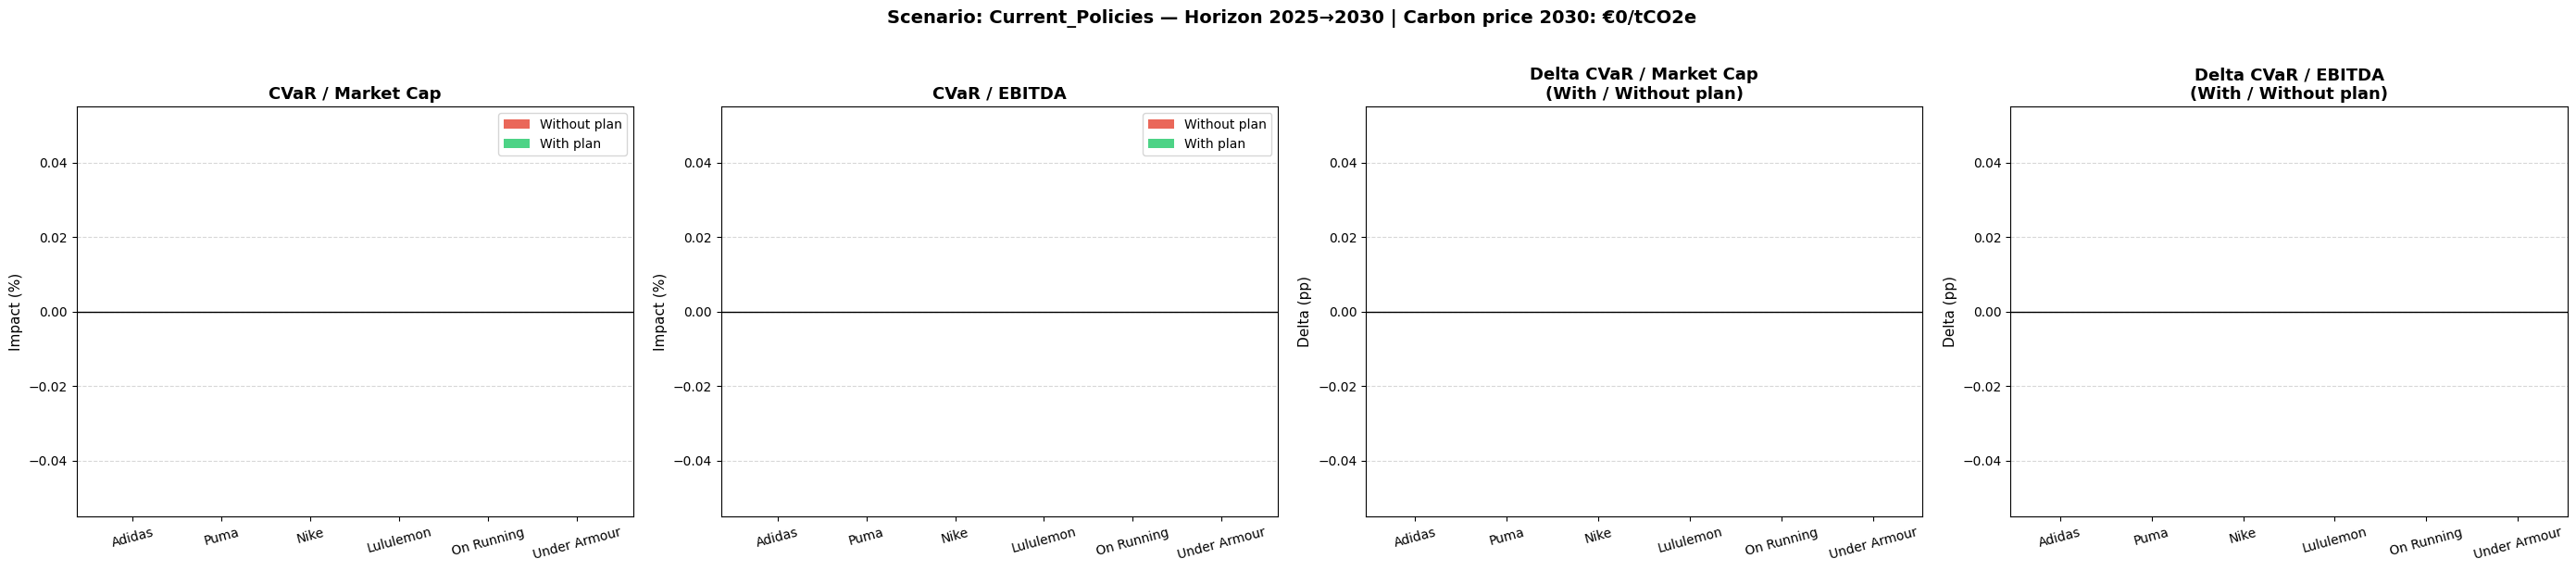


Running scenario: Current_Policies — Horizon 2025→2035

=== TABLE 3 — SCENARIO: Current_Policies — HORIZON 2035 ===


,Name,Ticker,gross_carbon_cost,net_carbon_cost,Green_Upside,annual_net_impact_avg,Cumulative_Impact,Annual_net_impact_WPlan,Cumulative_Impact_WPlan,CVaR_MktCap_NoPlan,CVaR_EBITDA_NoPlan,CVaR_MktCap_WithPlan,CVaR_EBITDA_WithPlan,Delta_MktCap,Delta_EBITDA
0,Adidas,ADS.DE,-0.0 M€,-0.0 M€,+0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€,+0.00%,+0.00%,+0.00%,+0.00%,+0.00 pp,+0.00 pp
1,Puma,PUM.DE,-0.0 M€,-0.0 M€,+0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€,+0.00%,+0.00%,+0.00%,+0.00%,+0.00 pp,+0.00 pp
2,Nike,NKE,-0.0 M€,-0.0 M€,+0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€,+0.00%,+0.00%,+0.00%,+0.00%,+0.00 pp,+0.00 pp
3,Lululemon,LULU,-0.0 M€,-0.0 M€,+0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€,+0.00%,+0.00%,+0.00%,+0.00%,+0.00 pp,+0.00 pp
4,On Running,ONON,-0.0 M€,-0.0 M€,+0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€,+0.00%,+0.00%,+0.00%,+0.00%,+0.00 pp,+0.00 pp
5,Under Armour,UAA,-0.0 M€,-0.0 M€,+0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€,+0.00%,+0.00%,+0.00%,+0.00%,+0.00 pp,+0.00 pp


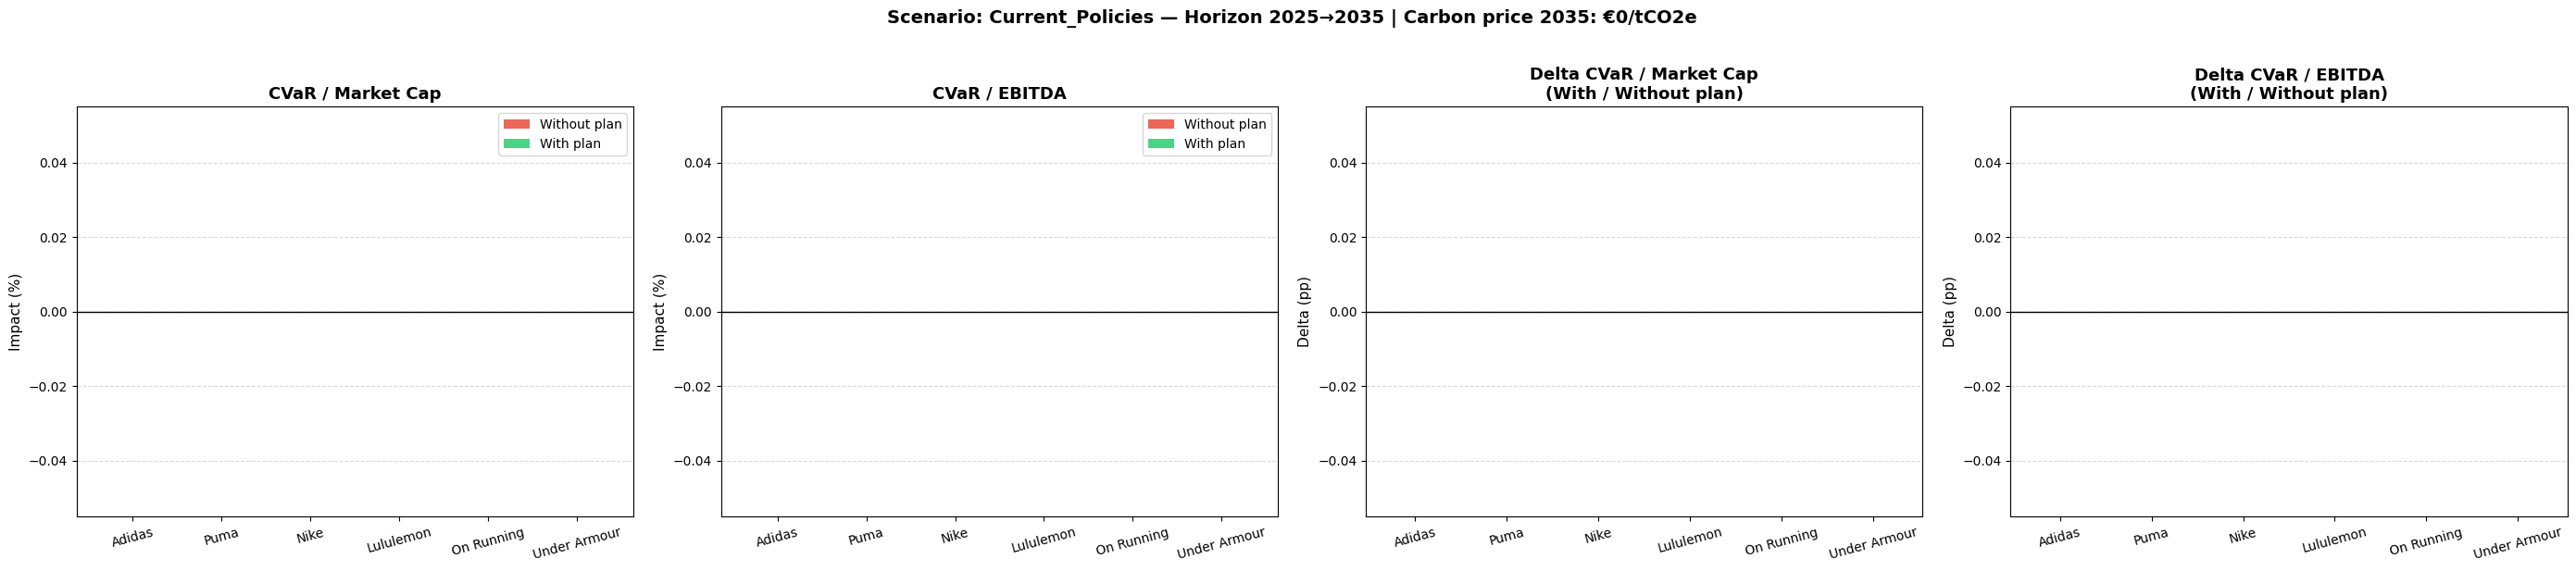


Running scenario: Delayed_Transition — Horizon 2025→2030

=== TABLE 3 — SCENARIO: Delayed_Transition — HORIZON 2030 ===


,Name,Ticker,gross_carbon_cost,net_carbon_cost,Green_Upside,annual_net_impact_avg,Cumulative_Impact,Annual_net_impact_WPlan,Cumulative_Impact_WPlan,CVaR_MktCap_NoPlan,CVaR_EBITDA_NoPlan,CVaR_MktCap_WithPlan,CVaR_EBITDA_WithPlan,Delta_MktCap,Delta_EBITDA
0,Adidas,ADS.DE,-0.0 M€,-0.0 M€,+0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€,+0.00%,+0.00%,+0.00%,+0.00%,+0.00 pp,+0.00 pp
1,Puma,PUM.DE,-0.0 M€,-0.0 M€,+0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€,+0.00%,+0.00%,+0.00%,+0.00%,+0.00 pp,+0.00 pp
2,Nike,NKE,-0.0 M€,-0.0 M€,+0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€,+0.00%,+0.00%,+0.00%,+0.00%,+0.00 pp,+0.00 pp
3,Lululemon,LULU,-0.0 M€,-0.0 M€,+0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€,+0.00%,+0.00%,+0.00%,+0.00%,+0.00 pp,+0.00 pp
4,On Running,ONON,-0.0 M€,-0.0 M€,+0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€,+0.00%,+0.00%,+0.00%,+0.00%,+0.00 pp,+0.00 pp
5,Under Armour,UAA,-0.0 M€,-0.0 M€,+0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€,+0.00%,+0.00%,+0.00%,+0.00%,+0.00 pp,+0.00 pp


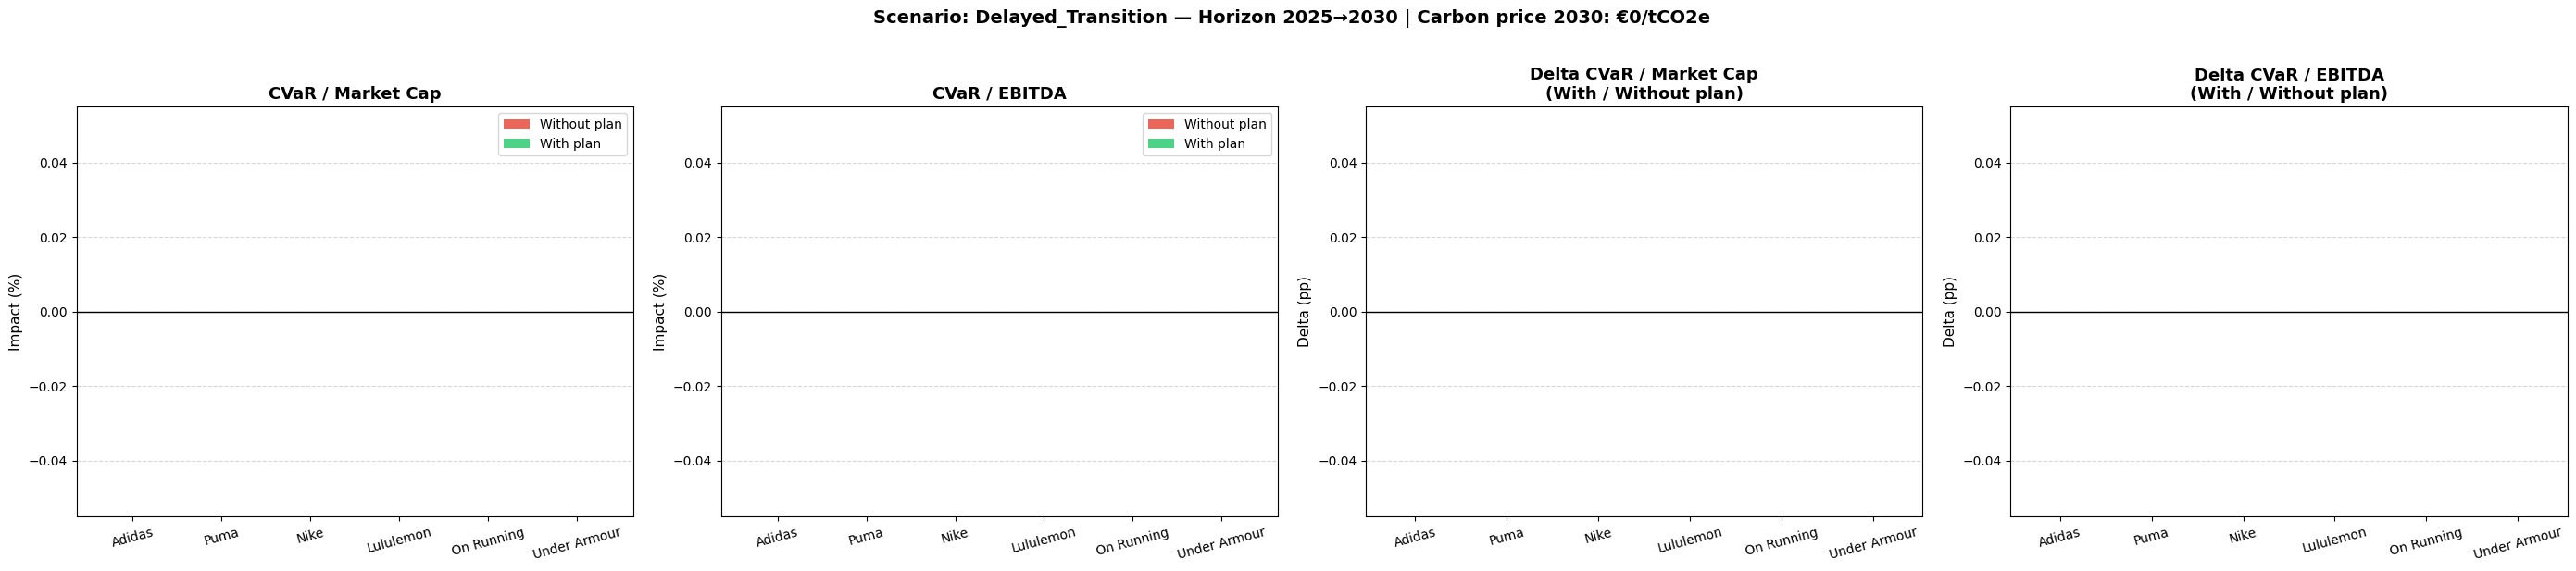


Running scenario: Delayed_Transition — Horizon 2025→2035

=== TABLE 3 — SCENARIO: Delayed_Transition — HORIZON 2035 ===


,Name,Ticker,gross_carbon_cost,net_carbon_cost,Green_Upside,annual_net_impact_avg,Cumulative_Impact,Annual_net_impact_WPlan,Cumulative_Impact_WPlan,CVaR_MktCap_NoPlan,CVaR_EBITDA_NoPlan,CVaR_MktCap_WithPlan,CVaR_EBITDA_WithPlan,Delta_MktCap,Delta_EBITDA
0,Adidas,ADS.DE,-839.9 M€,-839.9 M€,+0.0 M€,-76.4 M€,-839.9 M€,-59.9 M€,-659.2 M€,-3.23%,-34.07%,-2.53%,-26.74%,+0.70 pp,+7.33 pp
1,Puma,PUM.DE,-250.6 M€,-250.6 M€,+0.0 M€,-22.8 M€,-250.6 M€,-20.1 M€,-220.9 M€,-6.42%,-26.57%,-5.66%,-23.42%,+0.76 pp,+3.15 pp
2,Nike,NKE,"-1,104.5 M€","-1,104.5 M€",+0.0 M€,-100.4 M€,"-1,104.5 M€",-79.8 M€,-878.1 M€,-2.06%,-18.06%,-1.63%,-14.35%,+0.43 pp,+3.71 pp
3,Lululemon,LULU,-206.9 M€,-206.9 M€,+0.0 M€,-18.8 M€,-206.9 M€,-18.8 M€,-206.9 M€,-1.70%,-8.23%,-1.70%,-8.23%,+0.00 pp,+0.00 pp
4,On Running,ONON,-43.2 M€,-43.2 M€,+0.0 M€,-3.9 M€,-43.2 M€,-3.9 M€,-43.2 M€,-0.45%,-13.88%,-0.45%,-13.88%,+0.00 pp,+0.00 pp
5,Under Armour,UAA,-261.7 M€,-261.7 M€,+0.0 M€,-23.8 M€,-261.7 M€,-23.8 M€,-261.7 M€,-13.98%,-82.22%,-13.98%,-82.22%,+0.00 pp,+0.00 pp


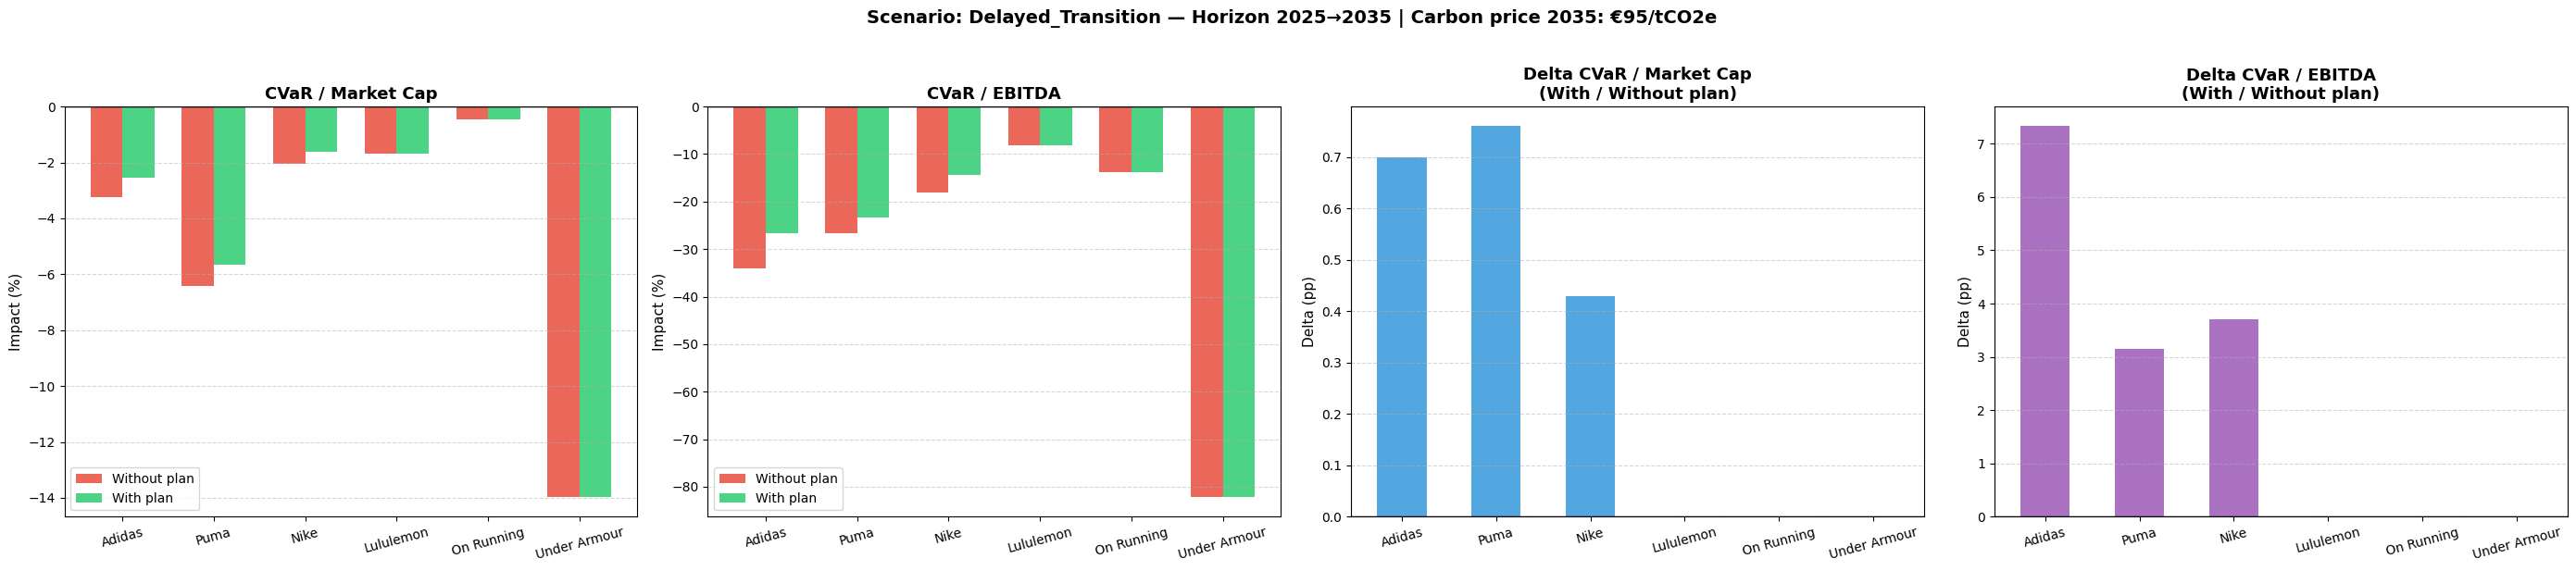


Running scenario: Net_Zero_2050 — Horizon 2025→2030

=== TABLE 3 — SCENARIO: Net_Zero_2050 — HORIZON 2030 ===


,Name,Ticker,gross_carbon_cost,net_carbon_cost,Green_Upside,annual_net_impact_avg,Cumulative_Impact,Annual_net_impact_WPlan,Cumulative_Impact_WPlan,CVaR_MktCap_NoPlan,CVaR_EBITDA_NoPlan,CVaR_MktCap_WithPlan,CVaR_EBITDA_WithPlan,Delta_MktCap,Delta_EBITDA
0,Adidas,ADS.DE,"-1,943.1 M€","-1,943.1 M€",+0.0 M€,-323.8 M€,"-1,943.1 M€",-278.7 M€,"-1,672.4 M€",-7.47%,-78.83%,-6.43%,-67.84%,+1.04 pp,+10.99 pp
1,Puma,PUM.DE,-517.5 M€,-517.5 M€,+0.0 M€,-86.3 M€,-517.5 M€,-79.5 M€,-477.2 M€,-13.27%,-54.87%,-12.23%,-50.60%,+1.04 pp,+4.27 pp
2,Nike,NKE,"-2,556.4 M€","-2,556.4 M€",+0.0 M€,-426.1 M€,"-2,556.4 M€",-369.5 M€,"-2,217.1 M€",-4.76%,-41.79%,-4.13%,-36.24%,+0.63 pp,+5.55 pp
3,Lululemon,LULU,-489.6 M€,-489.6 M€,+0.0 M€,-81.6 M€,-489.6 M€,-81.6 M€,-489.6 M€,-4.02%,-19.48%,-4.02%,-19.48%,+0.00 pp,+0.00 pp
4,On Running,ONON,-117.7 M€,-117.7 M€,+0.0 M€,-19.6 M€,-117.7 M€,-19.6 M€,-117.7 M€,-1.22%,-37.80%,-1.22%,-37.80%,+0.00 pp,+0.00 pp
5,Under Armour,UAA,-553.3 M€,-553.3 M€,+0.0 M€,-92.2 M€,-553.3 M€,-92.2 M€,-553.3 M€,-29.56%,-173.83%,-29.56%,-173.83%,+0.00 pp,+0.00 pp


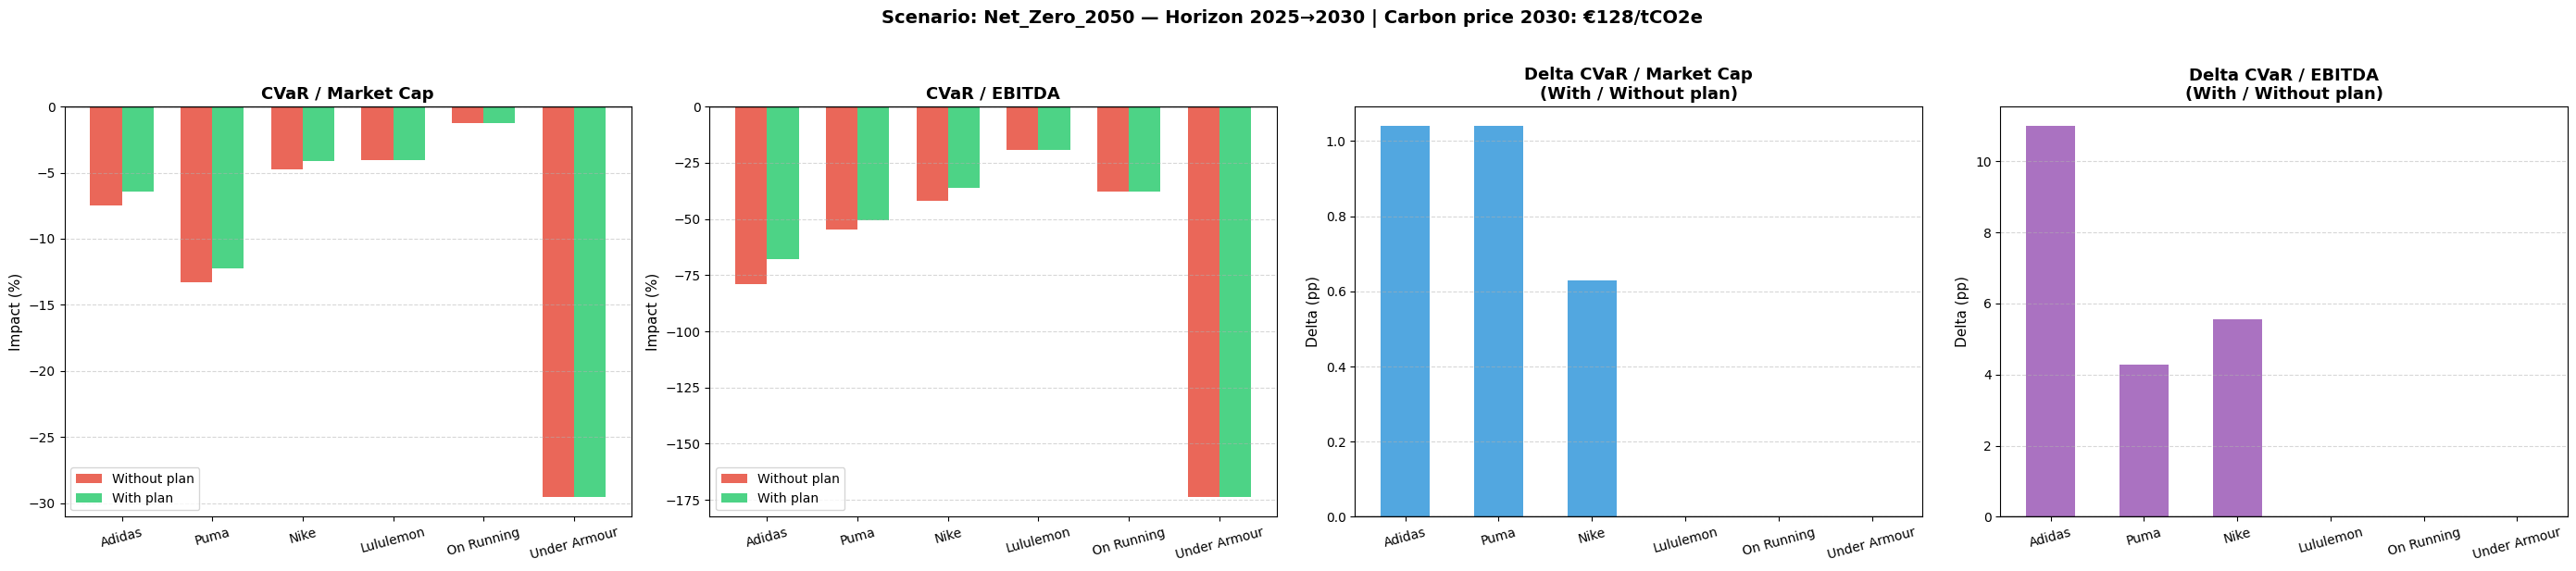


Running scenario: Net_Zero_2050 — Horizon 2025→2035

=== TABLE 3 — SCENARIO: Net_Zero_2050 — HORIZON 2035 ===


,Name,Ticker,gross_carbon_cost,net_carbon_cost,Green_Upside,annual_net_impact_avg,Cumulative_Impact,Annual_net_impact_WPlan,Cumulative_Impact_WPlan,CVaR_MktCap_NoPlan,CVaR_EBITDA_NoPlan,CVaR_MktCap_WithPlan,CVaR_EBITDA_WithPlan,Delta_MktCap,Delta_EBITDA
0,Adidas,ADS.DE,"-4,987.5 M€","-4,987.5 M€",+0.0 M€,-453.4 M€,"-4,987.5 M€",-369.2 M€,"-4,061.6 M€",-19.16%,-202.33%,-15.61%,-164.77%,+3.55 pp,+37.56 pp
1,Puma,PUM.DE,"-1,417.0 M€","-1,417.0 M€",+0.0 M€,-128.8 M€,"-1,417.0 M€",-115.5 M€,"-1,270.1 M€",-36.32%,-150.23%,-32.56%,-134.66%,+3.76 pp,+15.57 pp
2,Nike,NKE,"-6,560.0 M€","-6,560.0 M€",+0.0 M€,-596.4 M€,"-6,560.0 M€",-490.9 M€,"-5,400.0 M€",-12.21%,-107.23%,-10.05%,-88.27%,+2.16 pp,+18.96 pp
3,Lululemon,LULU,"-1,241.1 M€","-1,241.1 M€",+0.0 M€,-112.8 M€,"-1,241.1 M€",-112.8 M€,"-1,241.1 M€",-10.18%,-49.37%,-10.18%,-49.37%,+0.00 pp,+0.00 pp
4,On Running,ONON,-276.7 M€,-276.7 M€,+0.0 M€,-25.2 M€,-276.7 M€,-25.2 M€,-276.7 M€,-2.86%,-88.84%,-2.86%,-88.84%,+0.00 pp,+0.00 pp
5,Under Armour,UAA,"-1,494.7 M€","-1,494.7 M€",+0.0 M€,-135.9 M€,"-1,494.7 M€",-135.9 M€,"-1,494.7 M€",-79.86%,-469.56%,-79.86%,-469.56%,+0.00 pp,+0.00 pp


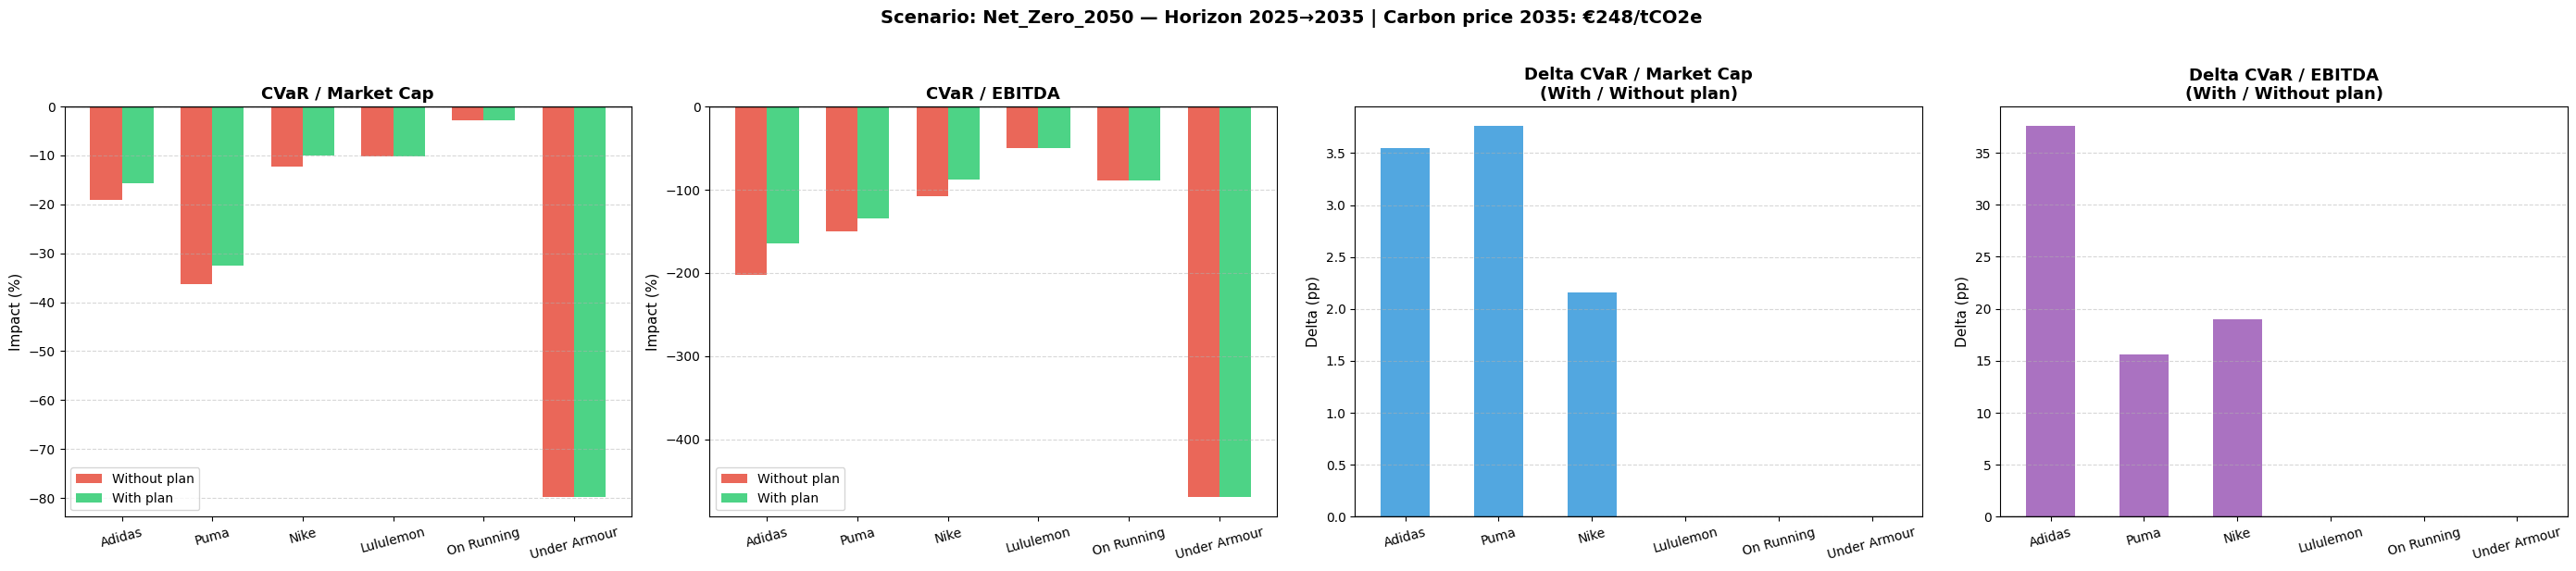

In [ ]:
# ── 10. Scenario loop — Table 3 (2030 + 2035) + charts ───────────────────────

import matplotlib.pyplot as plt

SCENARIOS   = ['Current_Policies', 'Delayed_Transition', 'Net_Zero_2050']
HORIZONS    = [('2030', HORIZON_MID), ('2035', HORIZON_FULL)]
all_results = {}

for scenario in SCENARIOS:
    for horizon_year, horizon in HORIZONS:
        HORIZON         = horizon
        ACTIVE_SCENARIO = scenario
        df_run          = df_companies.copy()
        carbon_prices   = CARBON_TRAJECTORY[scenario][:horizon]
        run_key         = f"{scenario}_{horizon_year}"

        print(f"\nRunning scenario: {scenario} — Horizon 2025→{horizon_year}")

        df_run[['CVaR_MktCap_NoPlan', 'CVaR_EBITDA_NoPlan']] = \
            df_run.apply(lambda r: calculate_cvar_and_sector(r, with_transition_plan=False), axis=1)
        df_run[['CVaR_MktCap_WithPlan', 'CVaR_EBITDA_WithPlan']] = \
            df_run.apply(lambda r: calculate_cvar_and_sector(r, with_transition_plan=True), axis=1)

        df_run['Delta_MktCap'] = df_run['CVaR_MktCap_WithPlan'] - df_run['CVaR_MktCap_NoPlan']
        df_run['Delta_EBITDA'] = df_run['CVaR_EBITDA_WithPlan'] - df_run['CVaR_EBITDA_NoPlan']
        df_run['Scenario']     = run_key

        intermediates = df_run.apply(lambda r: compute_intermediates(r, carbon_prices), axis=1)
        df_run        = pd.concat([df_run, intermediates], axis=1)
        all_results[run_key] = df_run

        carbon_horizon = carbon_prices[-1]
        print(f"\n=== TABLE 3 — SCENARIO: {scenario} — HORIZON {horizon_year} ===")
        display(display_table_3_scenario(df_run, scenario, horizon_year, carbon_prices))

        # ── Charts ────────────────────────────────────────────────────────────
        fig, axes = plt.subplots(1, 4, figsize=(28, 6))
        fig.suptitle(
            f'Scenario: {scenario} — Horizon 2025→{horizon_year} '
            f'| Carbon price {horizon_year}: €{carbon_horizon:.0f}/tCO2e',
            fontsize=14, fontweight='bold', y=1.02)

        x     = np.arange(len(df_run['Name']))
        width = 0.35

        axes[0].bar(x - width/2, df_run['CVaR_MktCap_NoPlan'], width, label='Without plan', color='#e74c3c', alpha=0.85)
        axes[0].bar(x + width/2, df_run['CVaR_MktCap_WithPlan'], width, label='With plan', color='#2ecc71', alpha=0.85)
        axes[0].set_title('CVaR / Market Cap', fontsize=13, fontweight='bold')
        axes[0].set_ylabel('Impact (%)', fontsize=11)
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(df_run['Name'], rotation=15)
        axes[0].axhline(0, color='black', linewidth=1)
        axes[0].legend()
        axes[0].grid(axis='y', linestyle='--', alpha=0.5)

        axes[1].bar(x - width/2, df_run['CVaR_EBITDA_NoPlan'], width, label='Without plan', color='#e74c3c', alpha=0.85)
        axes[1].bar(x + width/2, df_run['CVaR_EBITDA_WithPlan'], width, label='With plan', color='#2ecc71', alpha=0.85)
        axes[1].set_title('CVaR / EBITDA', fontsize=13, fontweight='bold')
        axes[1].set_ylabel('Impact (%)', fontsize=11)
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(df_run['Name'], rotation=15)
        axes[1].axhline(0, color='black', linewidth=1)
        axes[1].legend()
        axes[1].grid(axis='y', linestyle='--', alpha=0.5)

        axes[2].bar(x, df_run['Delta_MktCap'], width*1.5, color='#3498db', alpha=0.85)
        axes[2].set_title('Delta CVaR / Market Cap\n(With / Without plan)', fontsize=13, fontweight='bold')
        axes[2].set_ylabel('Delta (pp)', fontsize=11)
        axes[2].set_xticks(x)
        axes[2].set_xticklabels(df_run['Name'], rotation=15)
        axes[2].axhline(0, color='black', linewidth=1)
        axes[2].grid(axis='y', linestyle='--', alpha=0.5)

        axes[3].bar(x, df_run['Delta_EBITDA'], width*1.5, color='#9b59b6', alpha=0.85)
        axes[3].set_title('Delta CVaR / EBITDA\n(With / Without plan)', fontsize=13, fontweight='bold')
        axes[3].set_ylabel('Delta (pp)', fontsize=11)
        axes[3].set_xticks(x)
        axes[3].set_xticklabels(df_run['Name'], rotation=15)
        axes[3].axhline(0, color='black', linewidth=1)
        axes[3].grid(axis='y', linestyle='--', alpha=0.5)

        plt.tight_layout()
        plt.show()

# Reset HORIZON to full for Table 4
HORIZON = HORIZON_FULL

In [ ]:
# ── 11. Table 4 — Year-by-year detail (2025→2035, all scenarios) ─────────────

def display_table_4_yearly(all_results):
    """
    Detailed year-by-year breakdown for each company and scenario.
    Uses only the 2035 horizon runs for full 11-year detail.
    """
    rows = []

    for run_key, df_run in all_results.items():
        # Only use 2035 horizon runs for Table 4
        if not run_key.endswith('_2035'):
            continue
        scenario      = run_key.replace('_2035', '')
        carbon_prices = CARBON_TRAJECTORY[scenario]

        for _, company in df_run.iterrows():
            conv   = CURRENCY_TO_EUR.get(company.get('Currency', 'USD'), 0.855)
            ebitda = company['EBITDA'] * conv
            wacc   = calculate_wacc(company, conv)

            sbti_target_year_raw = company.get('SBTi_Target_Year', 2035)
            sbti_target_year     = 2035 if pd.isna(sbti_target_year_raw) else int(sbti_target_year_raw)

            for t in range(HORIZON_FULL):
                current_year = BASE_YEAR + t
                price_t      = carbon_prices[t]
                disc         = (1 + wacc) ** (t + 1)

                emissions_no_plan = company['Scope_1_2'] + company['Scope_3']
                gross_t           = emissions_no_plan * price_t
                net_t             = gross_t * (1 - company['Pass_Through'])
                up_t              = ebitda * company['%_of_Green_Revenue'] * GREEN_MARKET_GROWTH
                delta_cf_t        = up_t - net_t
                pv_delta_t        = delta_cf_t / disc

                eff_red_3_t = compute_scope3_reduction(
                    scope3_total_current = company['Scope_3'],
                    scope3_sbti_current  = company.get('Scope_3_SBTi_Current', np.nan),
                    scope3_sbti_baseline = company.get('Scope_3_SBTi_Baseline', np.nan),
                    reduction_plan       = company.get('Carbon_Reduction_Plan_Scope_3', np.nan),
                    sbti_target_year     = sbti_target_year,
                    current_year         = current_year
                )
                scope_3_wp    = company['Scope_3'] * (1 - eff_red_3_t)
                emissions_wp  = company['Scope_1_2'] + scope_3_wp
                gross_wp_t    = emissions_wp * price_t
                net_wp_t      = gross_wp_t * (1 - company['Pass_Through'])
                delta_cf_wp_t = up_t - net_wp_t
                pv_delta_wp_t = delta_cf_wp_t / disc

                rows.append({
                    'Scenario':          scenario,
                    'Name':              company['Name'],
                    'Ticker':            company['Ticker'],
                    'Year':              current_year,
                    'Carbon_Price':      round(price_t, 2),
                    'Emissions_NoPlan':  round(emissions_no_plan, 0),
                    'Emissions_WPlan':   round(emissions_wp, 0),
                    'Gross_Cost_NoPlan': gross_t,
                    'Net_Cost_NoPlan':   net_t,
                    'Gross_Cost_WPlan':  gross_wp_t,
                    'Net_Cost_WPlan':    net_wp_t,
                    'DeltaCF_NoPlan':    delta_cf_t,
                    'PV_DeltaCF_NoPlan': pv_delta_t,
                    'DeltaCF_WPlan':     delta_cf_wp_t,
                    'PV_DeltaCF_WPlan':  pv_delta_wp_t,
                })

    df_table4 = pd.DataFrame(rows)

    return df_table4.style \
        .set_caption("Table 4 — Year-by-Year Cash Flow Detail (Horizon 2025→2035)") \
        .format({
            'Carbon_Price':      '{:.2f} €/tCO2e',
            'Emissions_NoPlan':  '{:,.0f} tCO2e',
            'Emissions_WPlan':   '{:,.0f} tCO2e',
            'Gross_Cost_NoPlan': lambda x: f"-{x/1e6:,.1f} M€" if pd.notna(x) else '—',
            'Net_Cost_NoPlan':   lambda x: f"-{x/1e6:,.1f} M€" if pd.notna(x) else '—',
            'Gross_Cost_WPlan':  lambda x: f"-{x/1e6:,.1f} M€" if pd.notna(x) else '—',
            'Net_Cost_WPlan':    lambda x: f"-{x/1e6:,.1f} M€" if pd.notna(x) else '—',
            'DeltaCF_NoPlan':    lambda x: f"{x/1e6:,.1f} M€"  if pd.notna(x) else '—',
            'PV_DeltaCF_NoPlan': lambda x: f"{x/1e6:,.1f} M€"  if pd.notna(x) else '—',
            'DeltaCF_WPlan':     lambda x: f"{x/1e6:,.1f} M€"  if pd.notna(x) else '—',
            'PV_DeltaCF_WPlan':  lambda x: f"{x/1e6:,.1f} M€"  if pd.notna(x) else '—',
        }, na_rep='—') \
        .set_properties(**{'text-align': 'right', 'font-size': '11px'}) \
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#1e8449'), ('color', 'white'), ('text-align', 'center')]},
            {'selector': 'caption', 'props': [('font-size', '15px'), ('font-weight', 'bold'), ('padding', '8px')]}
        ])


print("=== TABLE 4 — YEAR-BY-YEAR DETAIL ===")
display(display_table_4_yearly(all_results))

=== TABLE 4 — YEAR-BY-YEAR DETAIL ===


,Scenario,Name,Ticker,Year,Carbon_Price,Emissions_NoPlan,Emissions_WPlan,Gross_Cost_NoPlan,Net_Cost_NoPlan,Gross_Cost_WPlan,Net_Cost_WPlan,DeltaCF_NoPlan,PV_DeltaCF_NoPlan,DeltaCF_WPlan,PV_DeltaCF_WPlan
0,Current_Policies,Adidas,ADS.DE,2025,0.00 €/tCO2e,"6,424,460 tCO2e","6,424,460 tCO2e",-0.0 M€,-0.0 M€,-0.0 M€,-0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€
1,Current_Policies,Adidas,ADS.DE,2026,0.00 €/tCO2e,"6,424,460 tCO2e","6,147,950 tCO2e",-0.0 M€,-0.0 M€,-0.0 M€,-0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€
2,Current_Policies,Adidas,ADS.DE,2027,0.00 €/tCO2e,"6,424,460 tCO2e","5,871,440 tCO2e",-0.0 M€,-0.0 M€,-0.0 M€,-0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€
3,Current_Policies,Adidas,ADS.DE,2028,0.00 €/tCO2e,"6,424,460 tCO2e","5,594,930 tCO2e",-0.0 M€,-0.0 M€,-0.0 M€,-0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€
4,Current_Policies,Adidas,ADS.DE,2029,0.00 €/tCO2e,"6,424,460 tCO2e","5,318,420 tCO2e",-0.0 M€,-0.0 M€,-0.0 M€,-0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€
5,Current_Policies,Adidas,ADS.DE,2030,0.00 €/tCO2e,"6,424,460 tCO2e","5,041,910 tCO2e",-0.0 M€,-0.0 M€,-0.0 M€,-0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€
6,Current_Policies,Adidas,ADS.DE,2031,0.00 €/tCO2e,"6,424,460 tCO2e","5,041,910 tCO2e",-0.0 M€,-0.0 M€,-0.0 M€,-0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€
7,Current_Policies,Adidas,ADS.DE,2032,0.00 €/tCO2e,"6,424,460 tCO2e","5,041,910 tCO2e",-0.0 M€,-0.0 M€,-0.0 M€,-0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€
8,Current_Policies,Adidas,ADS.DE,2033,0.00 €/tCO2e,"6,424,460 tCO2e","5,041,910 tCO2e",-0.0 M€,-0.0 M€,-0.0 M€,-0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€
9,Current_Policies,Adidas,ADS.DE,2034,0.00 €/tCO2e,"6,424,460 tCO2e","5,041,910 tCO2e",-0.0 M€,-0.0 M€,-0.0 M€,-0.0 M€,0.0 M€,0.0 M€,0.0 M€,0.0 M€
